# setup
imports and data loading

In [39]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# data cleaning/feature engineering
from sklearn.impute import SimpleImputer

In [40]:
def correcting_df_types(df):
    out = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            # print(f"{col} is numeric")
            pass
        elif df[col].dtype == 'object':
            out[col] = df[col].astype(str)
            values = set(df[col].astype(str).str.lower().str.strip().unique())
            if values <= {'yes', 'no', 'nan'}: # convert yes/no into bool
                out[col] = df[col].astype(str).str.lower()\
                    .str.strip().map({'yes': 1, 'no': 0, 'nan': np.nan})
            else:
                out[col] = df[col].astype(str)
                # print(f"-------- {col} --------")
                # print(f"type {df[col].dtype}")
                # print(f"converted from object to string")
                # print(f"examples: {', '.join(str(x) for x in df[col].unique())}")
                pass
        else:
            pass
            # print(f"-------- {col} --------")
            # print(f"type: {df[col].dtypes}")
            # print(f"examples: {', '.join(str(x) for x in df[col].unique()[:5])}")
    return out

def mapping_categories(df):
    # converting string into int for ordinal cols, and keep as is for nominal cols
    # ============================================================
    # ORDINAL CATEGORICALS
    # ============================================================
    general_health_map = {
        "Excellent": 5,
        "Very good": 4,
        "Good": 3,
        "Fair": 2,
        "Poor": 1,
    }

    last_checkup_map = {
        "Within past year (anytime less than 12 months ago)": 0.5,
        "Within past 2 years (1 year but less than 2 years ago)": 1.5,
        "Within past 5 years (2 years but less than 5 years ago)": 3.5,
        "5 or more years ago": 7.5,
    }

    diabetes_map = {
        "No": 0,
        "No, pre-diabetes or borderline diabetes": 1,
        "Yes, but only during pregnancy (female)": 2,
        "Yes": 3,
    }

    smoker_map = {
        "Never smoked": 0,
        "Former smoker": 1,
        "Current smoker - now smokes some days": 2,
        "Current smoker - now smokes every day": 3,
    }

    ecig_map = {
        "Never used e-cigarettes in my entire life": 0,
        "Not at all (right now)": 1,
        "Use them some days": 2,
        "Use them every day": 3,
    }

    covid_map = {
        "No": 0,
        "Tested positive using home test without a health professional": 1,
        "Yes": 2,
    }

    # ============================================================
    # NUMERICAL RANGES -> MIDPOINTS
    # ============================================================

    age_map = {
        "Age 18 to 24": 21,
        "Age 25 to 29": 27,
        "Age 30 to 34": 32,
        "Age 35 to 39": 37,
        "Age 40 to 44": 42,
        "Age 45 to 49": 47,
        "Age 50 to 54": 52,
        "Age 55 to 59": 57,
        "Age 60 to 64": 62,
        "Age 65 to 69": 67,
        "Age 70 to 74": 72,
        "Age 75 to 79": 77,
        "Age 80 or older": 85,
    }

    removed_teeth_map = {
        "None of them": 0,
        "1 to 5": 3,
        "6 or more, but not all": 16,
        "All": 32,
    }

    # ============================================================
    # APPLY MAPPINGS
    # ============================================================
    out = df.copy()
    out["GeneralHealth"] = (
        df["GeneralHealth"]
        .map(general_health_map)
        .astype("float64")
    )

    out["LastCheckupTime"] = (
        df["LastCheckupTime"]
        .map(last_checkup_map)
        .astype("float64")
    )

    out["HadDiabetes"] = (
        df["HadDiabetes"]
        .map(diabetes_map)
        .astype("float64")
    )

    out["SmokerStatus"] = (
        df["SmokerStatus"]
        .map(smoker_map)
        .astype("float64")
    )

    out["ECigaretteUsage"] = (
        df["ECigaretteUsage"]
        .map(ecig_map)
        .astype("float64")
    )

    out["CovidPos"] = (
        df["CovidPos"]
        .map(covid_map)
        .astype("float64")
    )

    out["AgeCategory"] = (
        df["AgeCategory"]
        .map(age_map)
        .astype("float64")
    )

    out["RemovedTeeth"] = (
        df["RemovedTeeth"]
        .map(removed_teeth_map)
        .astype("float64")
    )

    # ============================================================
    # NOMINAL CATEGORICALS
    # leave as categorical for one-hot encoding later
    # ============================================================

    nominal_cols = [
        "State",
        "Sex",
        "RaceEthnicityCategory",
        "TetanusLast10Tdap"
    ]

    for col in nominal_cols:
        out[col] = df[col].astype("category")
    return out

def handle_missing(df):
    out = df.copy()
    for col in out:
        if out[col].dtype == 'float64':
            if out[col].isna().sum() != 0:
                missingness_indicator = col+'missing'
                print(f'missineness {col} = {out[col].isna().sum()}')
                out[missingness_indicator] = out[col].isna()
                out[col] = out[col].fillna(out[col].median())
        elif out[col].dtype == 'category':
            out[col] = out[col].cat.add_categories(["missing"]).fillna("missing")
        else:
            # print(col)
            pass
    return out

In [41]:
# load dataset and clean
data = pd.read_csv('data/heart_2022_with_nans.csv')
data = data.dropna(subset=['HadHeartAttack']) # dropping all rows where target variable is missing
data = correcting_df_types(data)
data_mapped = mapping_categories(data)
data_imputed = handle_missing(data_mapped)
data_imputed.head(5)

missineness GeneralHealth = 1095
missineness PhysicalHealthDays = 10597
missineness MentalHealthDays = 8792
missineness LastCheckupTime = 8041
missineness PhysicalActivities = 972
missineness SleepHours = 5196
missineness RemovedTeeth = 11010
missineness HadAngina = 3588
missineness HadStroke = 1070
missineness HadAsthma = 1437
missineness HadSkinCancer = 2764
missineness HadCOPD = 1838
missineness HadDepressiveDisorder = 2421
missineness HadKidneyDisease = 1614
missineness HadArthritis = 2313
missineness HadDiabetes = 813
missineness DeafOrHardOfHearing = 20278
missineness BlindOrVisionDifficulty = 21190
missineness DifficultyConcentrating = 23795
missineness DifficultyWalking = 23604
missineness DifficultyDressingBathing = 23513
missineness DifficultyErrands = 25231
missineness SmokerStatus = 34941
missineness ECigaretteUsage = 35143
missineness ChestScan = 55288
missineness AgeCategory = 8807
missineness HeightInMeters = 28141
missineness WeightInKilograms = 41466
missineness BMI = 

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,AgeCategorymissing,HeightInMetersmissing,WeightInKilogramsmissing,BMImissing,AlcoholDrinkersmissing,HIVTestingmissing,FluVaxLast12missing,PneumoVaxEvermissing,HighRiskLastYearmissing,CovidPosmissing
0,Alabama,Female,4.0,0.0,0.0,0.5,0.0,8.0,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
1,Alabama,Female,5.0,0.0,0.0,0.5,0.0,6.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,Alabama,Female,4.0,2.0,3.0,0.5,1.0,5.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,Alabama,Female,5.0,0.0,0.0,0.5,1.0,7.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
4,Alabama,Female,2.0,2.0,0.0,0.5,1.0,9.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


# EDA
- visualize distributions of variables, assess missingness, assess correlation between target and features

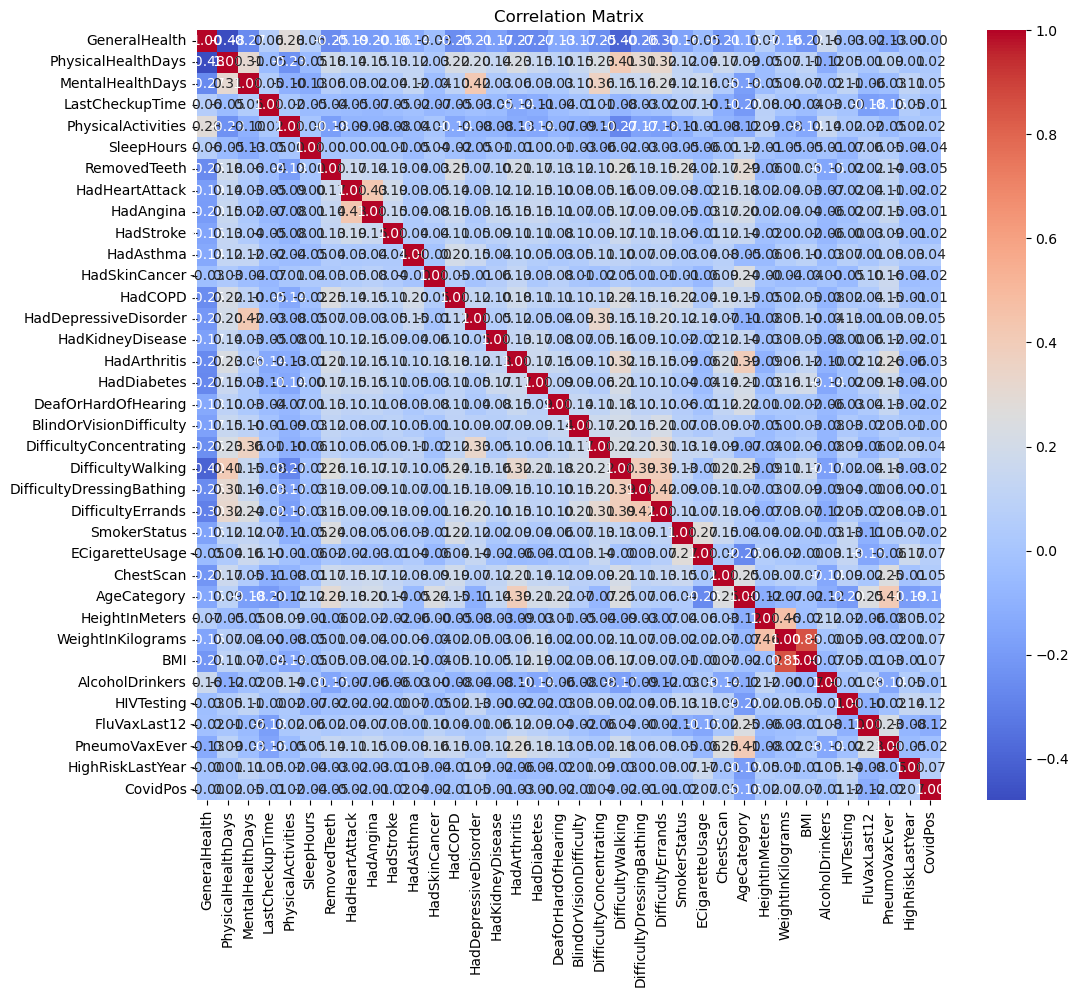

In [42]:
# heatmap correlation matrix
num_df = data_imputed.select_dtypes(include=['float64'])
plt.figure(figsize=(12, 10))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Baseline Model
### Linear Regression

In [43]:
# Baseline Model: Logistic Regression

# Imports

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

Baseline Model #1: Logistic Regression with df (without much preprocessing)
- changed boolean columns to integers for modeling
- only selected numeric columns for modeling, dropped rows with missing values


In [92]:
imputed_df_numeric = df.copy()
# bool_cols = imputed_df_numeric.select_dtypes(include='bool').columns
# imputed_df_numeric[bool_cols] = imputed_df_numeric[bool_cols].astype('Int64')
imputed_df_numeric['HadHeartAttack'] = imputed_df_numeric['HadHeartAttack'].astype('Int64')
imputed_df_numeric = imputed_df_numeric.select_dtypes(include='number')

imputed_df_numeric = imputed_df_numeric.dropna()


# Split features and target
X1 = imputed_df_numeric.drop(columns=['HadHeartAttack'])
y1 = imputed_df_numeric['HadHeartAttack']

# Train/val/test split (80/10/10)
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.5, random_state=42, stratify=y1_temp
)

# Scale features
scaler1 = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_val = scaler1.transform(X1_val)
X1_test = scaler1.transform(X1_test)

# Fit model
model1 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model1.fit(X1_train, y1_train)

# Evaluate on validation set
print("=== [Block 1] Validation Set ===")
y1_val_pred = model1.predict(X1_val)
y1_val_prob = model1.predict_proba(X1_val)[:, 1]
print(classification_report(y1_val, y1_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_val, y1_val_pred))
print("ROC-AUC Score:", roc_auc_score(y1_val, y1_val_prob))

print("_________________________________________________________________\n")

# Evaluate on test set
print("=== [Block 1] Test Set ===")
y1_test_pred = model1.predict(X1_test)
y1_test_prob = model1.predict_proba(X1_test)[:, 1]
print(classification_report(y1_test, y1_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_test, y1_test_pred))
print("ROC-AUC Score:", roc_auc_score(y1_test, y1_test_prob))

=== [Block 1] Validation Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.73      0.83     31336
         1.0       0.14      0.76      0.24      1861

    accuracy                           0.73     33197
   macro avg       0.56      0.74      0.54     33197
weighted avg       0.93      0.73      0.80     33197

Confusion Matrix:
 [[22725  8611]
 [  440  1421]]
ROC-AUC Score: 0.8191105192963557
_________________________________________________________________

=== [Block 1] Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.72      0.83     31337
         1.0       0.14      0.77      0.24      1861

    accuracy                           0.72     33198
   macro avg       0.56      0.75      0.53     33198
weighted avg       0.93      0.72      0.80     33198

Confusion Matrix:
 [[22555  8782]
 [  426  1435]]
ROC-AUC Score: 0.8180700566377639


Baseline Model #2: Logistic Regression with data_imputed (after preprocessing)

In [89]:
# BASELINE MODEL: LOGISTIC REGRESSION with data_imputed (and cleaned)

X2 = data_imputed.drop(columns=['HadHeartAttack']).select_dtypes(include=['float64', 'number'])
y2 = data_imputed['HadHeartAttack']

# Train/val/test split (80/10/10)
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.5, random_state=42, stratify=y2_temp
)

# Scale features
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_val = scaler2.transform(X2_val)
X2_test = scaler2.transform(X2_test)

# Fit model
model2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model2.fit(X2_train, y2_train)

# Evaluate on validation set
print("=== [Block 2] Validation Set ===")
y2_val_pred = model2.predict(X2_val)
y2_val_prob = model2.predict_proba(X2_val)[:, 1]
print(classification_report(y2_val, y2_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_val, y2_val_pred))
print("ROC-AUC Score:", roc_auc_score(y2_val, y2_val_prob))

print("_________________________________________________________________\n")

# Evaluate on test set
print("=== [Block 2] Test Set ===")
y2_test_pred = model2.predict(X2_test)
y2_test_prob = model2.predict_proba(X2_test)[:, 1]
print(classification_report(y2_test, y2_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_test_pred))
print("ROC-AUC Score:", roc_auc_score(y2_test, y2_test_prob))

=== [Block 2] Validation Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     41696
         1.0       0.21      0.75      0.33      2511

    accuracy                           0.83     44207
   macro avg       0.60      0.79      0.61     44207
weighted avg       0.94      0.83      0.87     44207

Confusion Matrix:
 [[34667  7029]
 [  630  1881]]
ROC-AUC Score: 0.8772144792383962
_________________________________________________________________

=== [Block 2] Test Set ===
              precision    recall  f1-score   support

         0.0       0.98      0.84      0.90     41696
         1.0       0.22      0.75      0.34      2511

    accuracy                           0.83     44207
   macro avg       0.60      0.79      0.62     44207
weighted avg       0.94      0.83      0.87     44207

Confusion Matrix:
 [[34854  6842]
 [  620  1891]]
ROC-AUC Score: 0.8817673552562127
